In [1]:
%load_ext autoreload
%autoreload 2

# A Deep Dive into Bayesian Model Comparison with BayesFlow

_Author: Jerry M. Huang_

In this notebook, we take a deep dive into Bayesian model comparison by demonstrating the `ModelComparisonWorkflow` in BayesFlow, focusing on **PMP (Posterior Model Probability) scoring rules** — where the network outputs softmax probabilities over all models.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numba import njit

import bayesflow as bf
from bayesflow.workflows import ModelComparisonWorkflow
import bayesflow.diagnostics.plots as bf_plots

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [3]:
rng = np.random.default_rng(seed=2026)

## Two families of scoring rules

BayesFlow supports two families of scoring rules for model comparison:

**PMP (Posterior Model Probability) rules** — the network outputs softmax probabilities over all models.  Diagnostics: confusion matrix and calibration curves.

| Class | Loss |
|-------|------|
| `CrossEntropyScore` | Categorical cross-entropy (default) |
| `SquaredScore` | Brier score (squared error on softmax probabilities) |
| `PolynomialScore` | Polynomial scoring rule; `alpha=2` recovers the Brier score |

**Bayes factor rules** — the network outputs M−1 log Bayes factors log K_{k,ref} relative to a reference model.  Diagnostics: blind coverage test and Bayes factor recovery.

| Class | Notes |
|-------|-------|
| `ExponentialScore` | Baseline Bayes factor rule |
| `LogisticScore` | Softplus-based; numerically more stable |
| `AlphaExponentialScore` | Exponential × polynomial envelope (default α=0.5) |
| `LPOPExponentialScore` | **Recommended** — l-POP transform before exp |
| `AlphaLogExponentialScore` | Log-sum-exp variant (default α=1.0) |

In [4]:
from bayesflow.scoring_rules import (
    CrossEntropyScore,
    SquaredScore,
    PolynomialScore,
    LogisticScore,
    ExponentialScore,
    LPOPExponentialScore,
    AlphaExponentialScore,
    AlphaLogExponentialScore
)

## Bayes Factor Scoring Rules — Gaussian Noise Example

Having explored PMP scoring rules, we now turn to **direct Bayes factor estimation**. Rather than outputting softmax probabilities, the network is trained to produce $\log K_{k,\,\text{ref}}$ — the log Bayes factor of each competing model relative to a fixed reference.

Because the example below uses conjugate Gaussian models, exact log Bayes factors are available in closed form, letting us verify network accuracy with `bayes_factor_recovery` alongside the `blind_coverage` diagnostic.


### Four Gaussian models with different priors

All four models share the same observation model $x_i \mid \mu \sim \mathcal{N}(\mu, 1)$ but place different Gaussian priors on the location $\mu$:

| Model | Observation model | Prior |
|-------|-------------------|-------|
| $M_1$ (ref.) | $x_i \mid \mu \sim \mathcal{N}(\mu,\ 1)$ | $\mu \sim \mathcal{N}(0,\ 1^2)$ — wide, centered |
| $M_2$ | $x_i \mid \mu \sim \mathcal{N}(\mu,\ 1)$ | $\mu \sim \mathcal{N}(0,\ 0.5^2)$ — narrow, centered |
| $M_3$ | $x_i \mid \mu \sim \mathcal{N}(\mu,\ 1)$ | $\mu \sim \mathcal{N}(1,\ 1^2)$ — wide, shifted |
| $M_4$ | $x_i \mid \mu \sim \mathcal{N}(\mu,\ 1)$ | $\mu \sim \mathcal{N}(1,\ 0.5^2)$ — narrow, shifted |

Because $\sigma=1$ is fixed and each prior is conjugate Gaussian, integrating out $\mu$ gives a closed-form marginal likelihood:

$$
\log p(\mathbf{x} \mid M_k) =
  -\frac{n}{2}\log(2\pi)
  - \frac{1}{2}\log\!\left(1 + n\tau_k^2\right)
  - \frac{1}{2}\!\left[
      \sum_i x_i^2
      + \frac{\mu_{0,k}^2}{\tau_k^2}
      - \frac{\displaystyle\left(n\bar{x} + \frac{\mu_{0,k}}{\tau_k^2}\right)^2}{\displaystyle n + \frac{1}{\tau_k^2}}
    \right]
$$

Ground-truth log Bayes factors $\log K_{k,1} = \log p(\mathbf{x}\mid M_k) - \log p(\mathbf{x}\mid M_1)$ are computed analytically per dataset and fed to `bayes_factor_recovery` to validate the network.

In [5]:
N_OBS = 50  # observations per dataset

# (mu0, tau) for each model's prior mu ~ N(mu0, tau^2)
PRIOR_PARAMS = [
    (0.0, 1.0),   # M1 (ref): wide, centered
    (0.0, 0.5),   # M2: narrow, centered
    (1.0, 1.0),   # M3: wide, shifted
    (1.0, 0.5)
]

In [6]:
def prior_1():
    return dict(mu=np.random.normal(loc=0.0, scale=1.0))

def prior_2():
    return dict(mu=np.random.normal(loc=0.0, scale=0.5))

def prior_3():
    return dict(mu=np.random.normal(loc=1.0, scale=1.0))

def prior_4():
    return dict(mu=np.random.normal(loc=1.0, scale=0.5))

def likelihood(mu, **kwargs):
    x = np.random.normal(loc=mu, scale=1.0, size=(N_OBS, 1)).astype(np.float32)
    return dict(x=x)


bf_simulators = [
    bf.make_simulator([prior_1, likelihood]),
    bf.make_simulator([prior_2, likelihood]),
    bf.make_simulator([prior_3, likelihood]),
    bf.make_simulator([prior_4, likelihood])
]


def log_marginal_likelihood(x, mu0, tau):
    """Analytic log marginal likelihood: x_i | mu ~ N(mu, 1), mu ~ N(mu0, tau^2)."""
    n = len(x)
    x_bar = np.mean(x)
    ss = np.sum(x ** 2)
    prec_prior = 1.0 / tau ** 2
    B = n * x_bar + mu0 * prec_prior
    A = n + prec_prior
    return (
        -n / 2 * np.log(2 * np.pi)
        - 0.5 * np.log(1.0 + n * tau ** 2)
        - 0.5 * (ss + mu0 ** 2 * prec_prior - B ** 2 / A)
    )


def compute_true_log_bfs(test_data, reference=0):
    """Compute analytic log BFs of shape (B, num_models-1) from simulated test data."""
    x_batch = test_data["x"]
    B = x_batch.shape[0]
    mu0_ref, tau_ref = PRIOR_PARAMS[reference]
    competing = [k for k in range(len(PRIOR_PARAMS)) if k != reference]
    log_bfs = np.zeros((B, len(competing)))
    for i, k in enumerate(competing):
        mu0_k, tau_k = PRIOR_PARAMS[k]
        for b in range(B):
            x = x_batch[b, :, 0].astype(np.float64)
            log_bfs[b, i] = (
                log_marginal_likelihood(x, mu0_k, tau_k)
                - log_marginal_likelihood(x, mu0_ref, tau_ref)
            )
    return log_bfs


In [10]:
bf_adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate("model_indices", into="inference_variables")
    .concatenate(["x"], into="summary_variables")
)

bf_workflow = ModelComparisonWorkflow(
    simulator=bf_simulators,
    adapter=bf_adapter,
    summary_network="time_series_transformer",
    scoring_rule=ExponentialScore(),
    standardize="all"
)

In [11]:
bf_history = bf_workflow.fit_online(
    epochs=50,
    num_batches_per_epoch=150,
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 2.6778 - scoring_rule/inference_scoring_rule: 2.6778
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5979 - scoring_rule/inference_scoring_rule: 2.5979
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5487 - scoring_rule/inference_scoring_rule: 2.5487
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5911 - scoring_rule/inference_scoring_rule: 2.5911
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2533 - scoring_rule/inference_scoring_rule: 2.2533
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4275 - scoring_rule/inference_scoring_rule: 2.4275
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5389 - scoring_rule/inference_scoring_rule: 2.5389
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6213 - scoring_rule/inference_scoring_rule: 2.6213
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4699 - scoring_rule/inference_scor

INFO:bayesflow:Training completed in 23.00 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Prediction completed in 0.03 seconds.
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


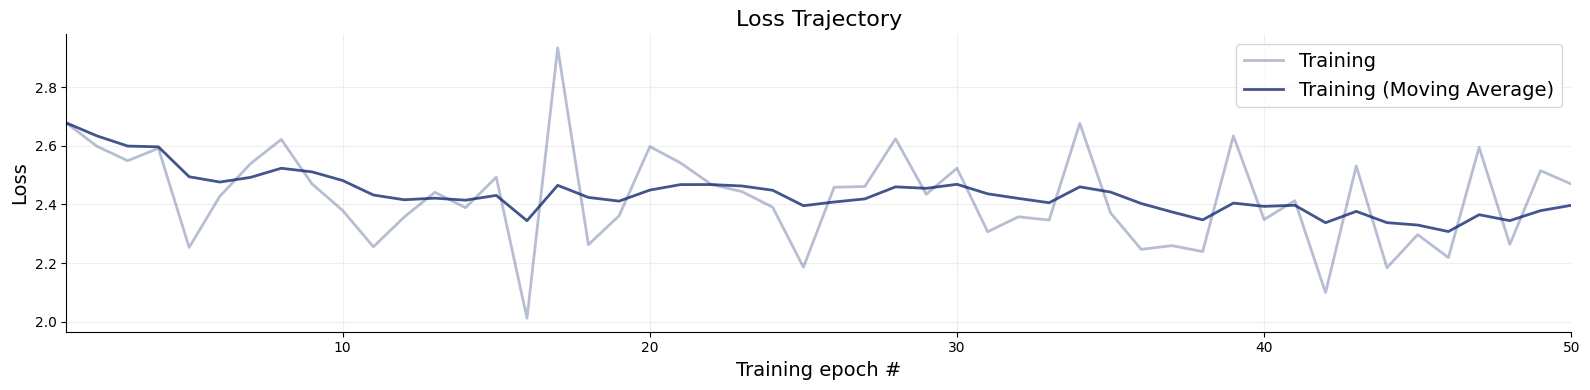

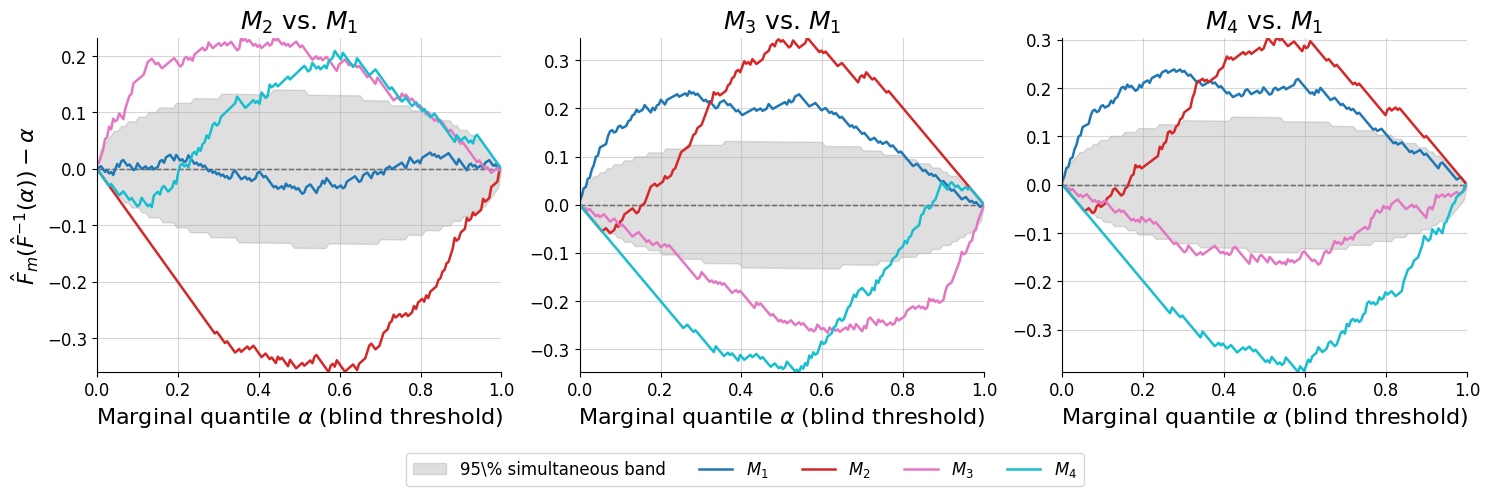

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


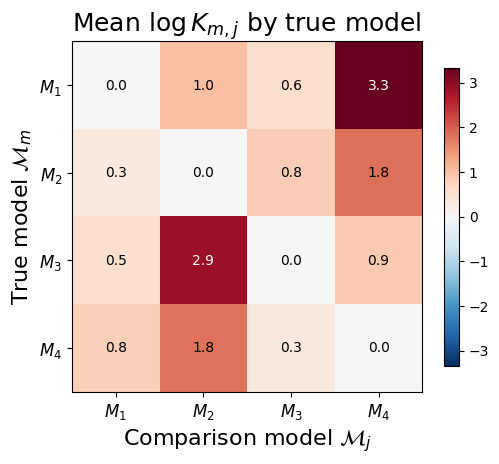

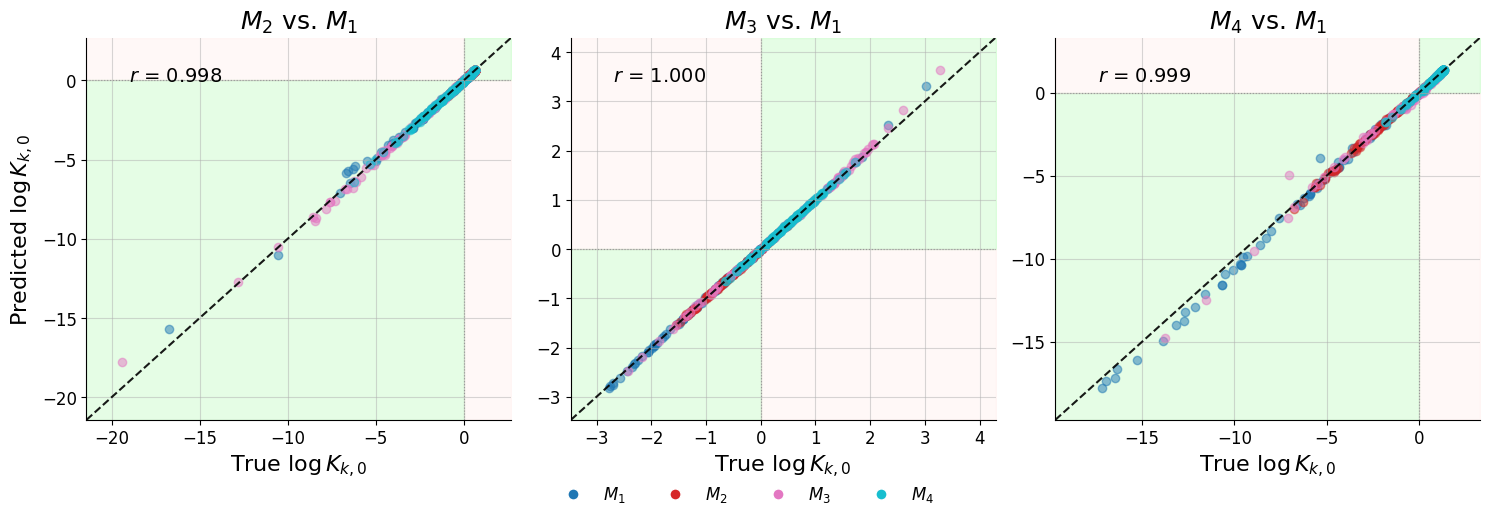

In [12]:
figs_bf = bf_workflow.plot_default_diagnostics(test_data=500, true_log_bfs_fn=compute_true_log_bfs)

### Comparing Bayes Factor Scoring Rules: $M_1$ vs $M_4$

To see how the five Bayes factor scoring rules differ in practice, we train one network per rule on a simpler two-model problem — $M_1$ ($\mu \sim \mathcal{N}(0,1)$) vs $M_4$ ($\mu \sim \mathcal{N}(1, 0.5^2)$) — for **10 epochs** each.  Ground-truth log Bayes factors are available in closed form, so we can assess recovery quality immediately.

Each panel in the figure below shows predicted $\log K_{4,1}$ against the analytic truth, coloured by the true generating model.  The Pearson correlation $r$ quantifies how well each rule tracks the truth after only 10 epochs of training.

In [ ]:
# 2-model setup: M1 (wide, centered) vs M4 (wide, shifted)
two_model_simulators = [
    bf.make_simulator([prior_1, likelihood]),
    bf.make_simulator([prior_4, likelihood]),
]

two_model_adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate("model_indices", into="inference_variables")
    .concatenate(["x"], into="summary_variables")
)

scoring_rules_2m = [
    ("Exponential",         ExponentialScore()),
    ("Logistic",            LogisticScore()),
    ("AlphaExponential",    AlphaExponentialScore()),
    ("AlphaLogExponential", AlphaLogExponentialScore()),
    ("LPOPExponential",     LPOPExponentialScore()),
]

# Train one network per scoring rule
workflows_2m = []
for name, sr in scoring_rules_2m:
    wf = ModelComparisonWorkflow(
        simulator=two_model_simulators,
        adapter=two_model_adapter,
        summary_network="time_series_transformer",
        scoring_rule=sr,
        standardize="all",
    )
    wf.fit_online(epochs=50, num_batches_per_epoch=150, batch_size=64)
    workflows_2m.append(wf)

# Shared test data — simulated once, reused across all rules
test_2m = workflows_2m[0].simulate(500)
true_log_bfs_2m = np.array([
    log_marginal_likelihood(test_2m["x"][b, :, 0].astype(np.float64), 1.0, 0.5)
    - log_marginal_likelihood(test_2m["x"][b, :, 0].astype(np.float64), 0.0, 1.0)
    for b in range(test_2m["x"].shape[0])
]).reshape(-1, 1)

# probs=False returns raw log BFs of shape (N, M-1), required by bayes_factor_recovery
for (name, _), wf in zip(scoring_rules_2m, workflows_2m):
    pred = wf.predict(conditions=test_2m, probs=False)
    fig = bf_plots.bayes_factor_recovery(
        pred_log_bayes_factors=pred,
        true_log_bayes_factors=true_log_bfs_2m,
        true_models=test_2m["model_indices"]
    )
    fig.suptitle(name, fontsize=15, y=1.02)
    plt.show()

## Simulators

To demonstrate with an application scenario, we discriminate between four models within the generalized autoregressive conditional heteroscedasticity (GARCH) model family, commonly used in computational finance.

| Model | Key feature |
|-------|-------------|
| ARCH(1) | Short-memory ARCH: volatility shocks decay in one step |
| GARCH(1,1) | Persistent volatility clustering, Gaussian innovations |
| GJR-GARCH(1,1) | Leverage effect: negative shocks inflate variance more |
| GARCH-t | GARCH(1,1) with Student-t innovations; heavier tails |

Rather than hand-crafting summary statistics, we feed the raw return series directly into a `TimeSeriesTransformer` summary network and let the network learn what to look at — a more principled and typically more powerful approach.

Each model is defined by a **prior function** that draws parameters, and all four share a single **likelihood function** that runs the GARCH recursion.  `bf.make_simulator` chains them so that the prior's output dict is forwarded automatically as keyword arguments to the likelihood.

The unified likelihood covers all four models via its optional parameters:

| Model | `beta` | `gamma` | `nu` |
|-------|--------|---------|------|
| ARCH(1) | 0 (default) | 0 (default) | None (default) |
| GARCH(1,1) | sampled | 0 (default) | None (default) |
| GJR-GARCH(1,1) | sampled | sampled | None (default) |
| GARCH-t | sampled | 0 (default) | sampled |

In [11]:
def arch_prior():
    return dict(
        omega=rng.uniform(5e-5, 2e-4),
        alpha=rng.uniform(0.15, 0.45),   # high α, no β — strong short-memory effect; α < 1 ensures stationarity
        beta =0.0,
        gamma=0.0,
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def garch_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        beta =rng.uniform(0.91, 0.96),   # very high persistence; clear gap above GJR's β; α + β ≤ 0.99
        gamma=0.0,
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def gjr_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        gamma=rng.uniform(0.10, 0.16),   # α + γ/2 + β ≤ 0.99; β sits clearly between ARCH (0) and GARCH (0.91+)
        beta =rng.uniform(0.83, 0.88),
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def garcht_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        beta =rng.uniform(0.91, 0.96),   # mirrors GARCH persistence; α + β ≤ 0.99
        gamma=0.0,
        nu   =rng.uniform(2.5, 4.5),     # ν > 2 ensures finite variance; entire range has distinctly heavy tails
        mu   =rng.uniform(-5e-4, 5e-4),
    )

In [12]:
@njit
def simulate_garch(omega, alpha, mu, beta, gamma, nu, T, burn_in):
    """JIT-compiled GARCH recursion. nu=inf selects Gaussian innovations."""
    T_total = T + burn_in
    returns = np.empty(T_total)
    eps = 0.0
    sigma2 = omega / max(1.0 - alpha - gamma * 0.5 - beta, 1e-6)
    use_gaussian = np.isinf(nu)

    for t in range(T_total):
        I_neg = 1.0 if eps < 0.0 else 0.0
        sigma2 = omega + (alpha + gamma * I_neg) * eps * eps + beta * sigma2
        if sigma2 < 1e-10:
            sigma2 = 1e-10
        elif sigma2 > 1.0:
            sigma2 = 1.0
        if use_gaussian:
            z = np.random.randn()
        else:
            z = np.random.standard_t(nu) * np.sqrt((nu - 2.0) / nu)
        eps = np.sqrt(sigma2) * z
        returns[t] = mu + eps

    out = returns[burn_in:].copy()
    for i in range(len(out)):
        if out[i] < -1.0:
            out[i] = -1.0
        elif out[i] > 1.0:
            out[i] = 1.0
    return out


def garch_model(omega, alpha, mu, beta=0.0, gamma=0.0, nu=None, T=500, burn_in=50, **kwargs):
    """Shared GARCH model for all variants.

    beta=0, gamma=0, nu=None/inf  →  ARCH(1)
    gamma=0, nu=None/inf          →  GARCH(1,1)
    nu=None/inf                   →  GJR-GARCH(1,1)
    nu provided and finite        →  GARCH-t (Student-t innovations scaled to unit variance)
    """
    nu_val = np.inf if (nu is None or np.isinf(float(nu))) else float(nu)
    out = simulate_garch(float(omega), float(alpha), float(mu),
                      float(beta), float(gamma), nu_val, T, burn_in)
    return {"returns": out[:, np.newaxis].astype(np.float32)}


# Warm up both JIT branches (Gaussian and Student-t) to pay compile cost once.
simulate_garch(1e-5, 0.1, 0.0, 0.8, 0.0, np.inf, 60, 10)
simulate_garch(1e-5, 0.1, 0.0, 0.8, 0.0, 5.0,    60, 10)
print("JIT warmup complete.")

JIT warmup complete.


In [13]:
arch_simulator      = bf.make_simulator([arch_prior, garch_model])
garch_simulator     = bf.make_simulator([garch_prior, garch_model])
gjr_simulator       = bf.make_simulator([gjr_prior, garch_model])
garcht_simulator    = bf.make_simulator([garcht_prior, garch_model])

simulators = [arch_simulator, garch_simulator, gjr_simulator, garcht_simulator]
model_names = ["ARCH", "GARCH", "GJR", "GARCH-t"]

### Prior predictive check

A single draw from each simulator illustrates the qualitative differences the network will learn to detect.

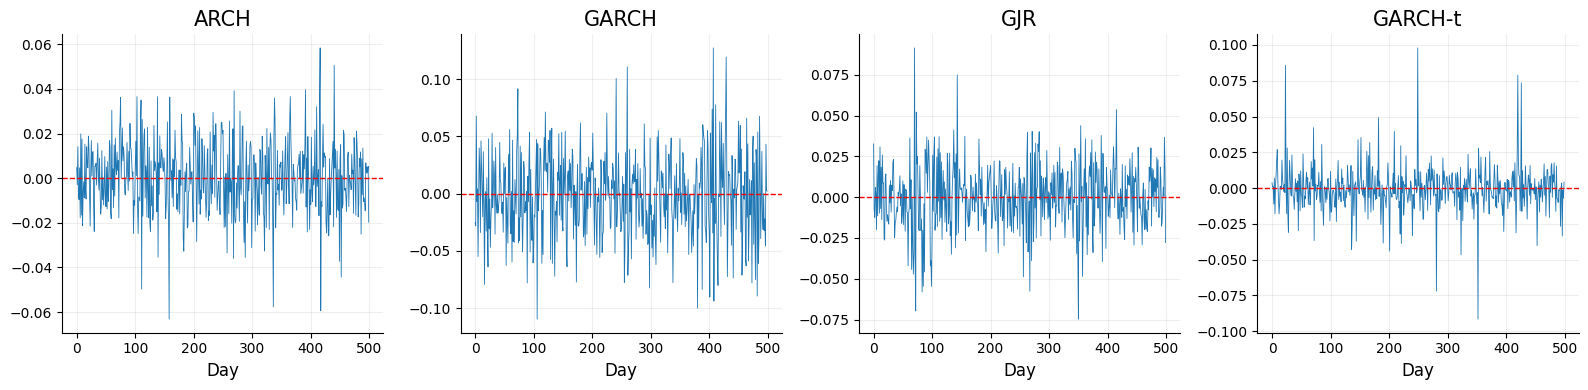

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, sim, name in zip(axes, simulators, model_names):
    path = sim.sample((5,))["returns"][4, :]
    sns.lineplot(path, linewidth=0.6, ax=ax, legend=False)
    ax.grid(alpha=0.2)
    ax.set_title(name, fontsize=15)
    ax.set_xlabel("Day", fontsize=12)
    ax.axhline(0, color="red", linewidth=1, linestyle="--")
    sns.despine()
plt.tight_layout()

In [15]:
garch_adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate("model_indices", into="inference_variables")
    .concatenate(["returns"], into="summary_variables")
)

## PMP Scoring Rules

PMP scoring rules train the network to output softmax probabilities over all models. The three available rules differ only in their loss function; they share the same network architecture and produce identical output shapes.

We train with the default `CrossEntropyScore`.  To switch to another PMP rule, pass `scoring_rule=SquaredScore()` or `scoring_rule=PolynomialScore(alpha=3.0)` — everything else stays the same.

In [16]:
pmp_workflow = ModelComparisonWorkflow(
    simulator=simulators,
    adapter=garch_adapter,
    summary_network="time_series_transformer",
    model_names=model_names,
    scoring_rule=CrossEntropyScore(), 
    standardize="all"
)

# Alternative PMP scoring rules (same API, just swap scoring_rule=):
#
# pmp_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=SquaredScore()
# )
#
# pmp_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=PolynomialScore(alpha=2.0)  # alpha=2 recovers Brier score
# )

In [17]:
history = pmp_workflow.fit_online(
    epochs=50,
    num_batches_per_epoch=150,
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 31ms/step - loss: 2.1169 - scoring_rule/inference_scoring_rule: 2.1169 
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1.8250 - scoring_rule/inference_scoring_rule: 1.8250
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1.9973 - scoring_rule/inference_scoring_rule: 1.9973
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1.6558 - scoring_rule/inference_scoring_rule: 1.6558
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1.8047 - scoring_rule/inference_scoring_rule: 1.8047
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1.3123 - scoring_rule/inference_scoring_rule: 1.3123
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 1.5060 - scoring_rule/inference_scoring_rule: 1.5060
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 1.2727 - scoring_rule/inference_scoring_rule: 1.2727
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 1.2626 - scoring_rule/inf

INFO:bayesflow:Training completed in 4.88 minutes.


### Diagnostics — PMP rules

`plot_default_diagnostics` detects the active scoring rule and automatically produces the appropriate plots. For PMP rules these are:

- **Loss curve** — training and validation cross-entropy over epochs.
- **Confusion matrix** — rows = true model, columns = predicted model (argmax of PMPs).
- **Calibration curves** — per-model ECE-annotated reliability diagrams.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Prediction completed in 8.35 seconds.


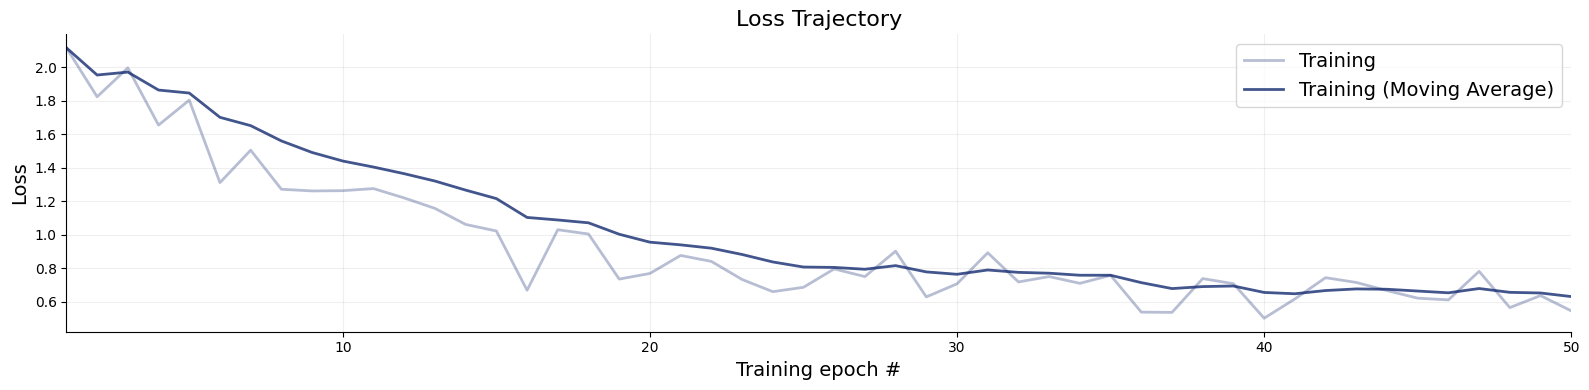

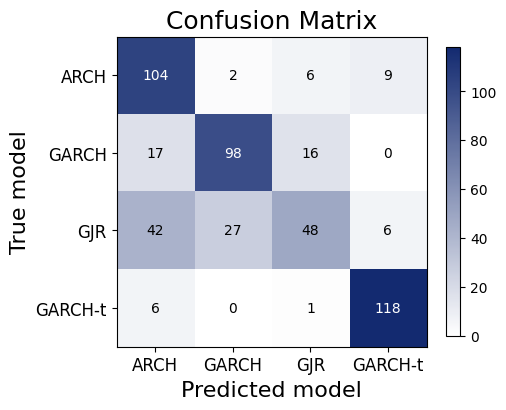

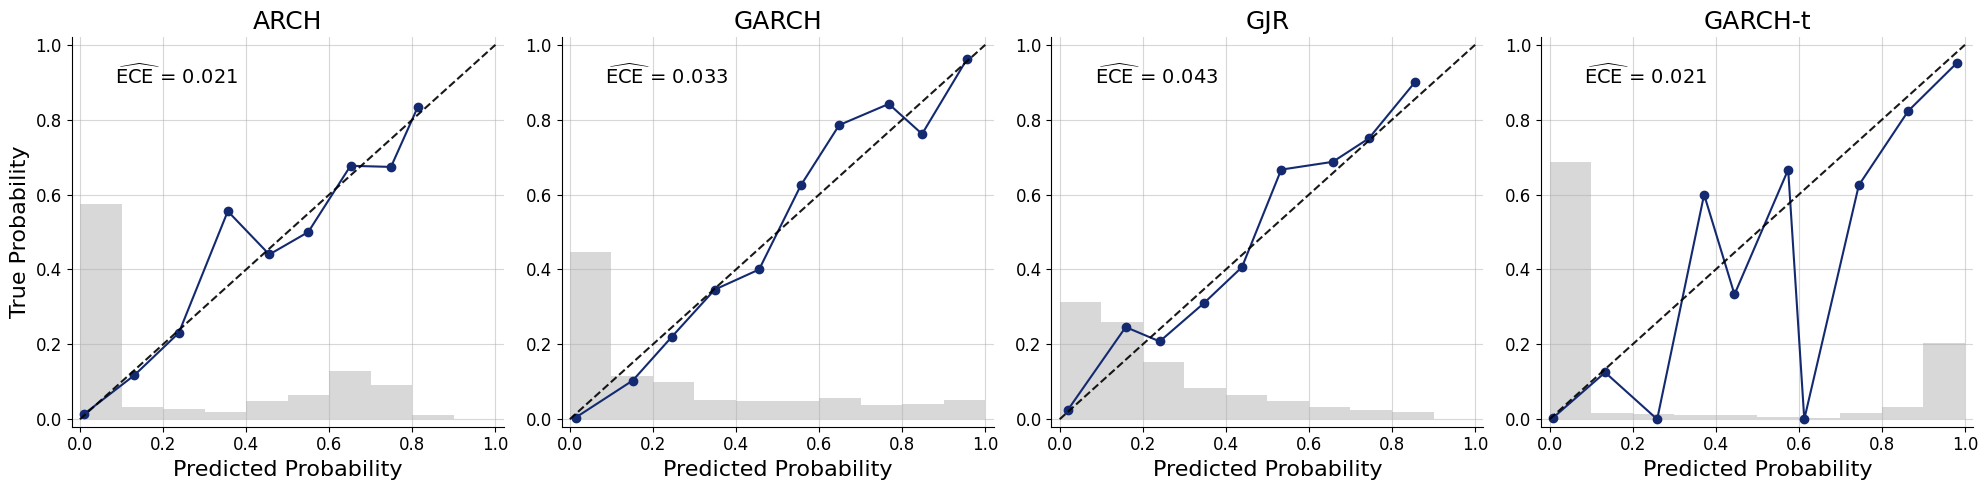

In [18]:
figures = pmp_workflow.plot_default_diagnostics(test_data=500)

Here is how we interpret each plot:

* The **confusion matrix** summarizes classification performance by showing, for each true generating model, how often the network's top prediction (argmax of the PMPs) agrees with it. Rows are the true generating model, columns are the predicted model, and each cell contains the fraction of test datasets in that true-model group assigned to each predicted class. A well-trained network concentrates mass on the diagonal, while residual off-diagonal confusion tends to appear between structurally similar pairs.

* The **calibration curves** assess whether the network's predicted probabilities are trustworthy as probability estimates and not just as rankings. Each panel is a reliability diagram for one model: the x-axis bins the predicted PMP $\hat{P}(M_k \mid \mathbf{y})$, the y-axis shows the empirical fraction of datasets in that bin that truly came from model $k$, and the ECE annotated on each panel is the weighted mean absolute deviation from the diagonal. A well-calibrated network tracks the diagonal closely with a low ECE; curves bowing above the diagonal indicate underconfidence, curves bowing below indicate overconfidence, and either can occur independently of how sharp the confusion matrix looks.